In [2]:
import sys
import os
import pandas as pd
from datetime import datetime

PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

# Импорты из нашего проекта
from task_agent import TaskEstimatorAgent
from models import Task
from config import Config


In [3]:
import numpy as np

# ===== Spark-блок отключен для локального запуска =====
# from pyspark.sql import SparkSession
# from pyspark.sql import HiveContext
# from pyspark.sql import Window
# from pyspark.sql.functions import col, lit, sum, count, coalesce, when, substring, concat
# from pyspark.sql.types import *
# import pyspark.sql.functions as F
# import pyspark.sql.types as T
#
# spark_application_name = 'strategy_rpp'
# POD_IP = os.environ['POD_IP']
# NS = os.environ['NAMESPACE']
# KEYTAB_USER = "ruaymn2"
# KEYTAB_PATH = "/home/jovyan/ruaymn2.keytab"
# spark = (
#     SparkSession
#     .builder
#     .appName(f"{KEYTAB_USER} notebook")
#     .config("spark.kerberos.keytab", KEYTAB_PATH)
#     .config("spark.kerberos.principal", KEYTAB_USER)
#     .enableHiveSupport()
#     .getOrCreate()
# )
# spark.sparkContext.setLogLevel("ERROR")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)
pd.set_option("display.float_format", lambda x: "%.3f" % x)
pd.set_option("display.max_colwidth", None)

print("Spark блок отключен. Используем Train_and_test.xlsx")


26/02/12 12:43:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting spark.hadoop.yarn.resourcemanager.principal to ruaymn2
26/02/12 12:43:34 WARN Utils: spark.dynamicAllocation.initialExecutors less than spark.dynamicAllocation.minExecutors is invalid, ignoring its setting, please update your configs.
26/02/12 12:43:34 WARN DomainSocketFactory: The short-circuit local reads feature cannot be used because libhadoop cannot be loaded.
26/02/12 12:43:36 WARN Utils: spark.dynamicAllocation.initialExecutors less than spark.dynamicAllocation.minExecutors is invalid, ignoring its setting, please update your configs.
INFO:SparkMonitorKernel:Client Connected ('127.0.0.1', 38552)


In [34]:
# spark.stop()  # отключено: локальный запуск без Spark


INFO:SparkMonitorKernel:Scala socket closed - empty data
INFO:SparkMonitorKernel:Socket Exiting Client Loop
INFO:SparkMonitorKernel:Starting socket thread, going to accept


In [4]:
# Spark-запросы к raw_jira_jira.changeitem отключены для локального прогона


In [11]:
agent = TaskEstimatorAgent()

import requests

response = requests.get(
    f"{Config.LLM_API_URL}/models",
    headers={"Authorization": f"Bearer {Config.API_KEY}"}
)

if response.status_code == 200:
    models = response.json()
    print("Доступные модели:")
    for model in models.get("data", [])[:10]:
        print(f"  - {model['id']}")
else:
    print(f"⚠️ Ошибка получения списка моделей: {response.status_code}")

print(f"\nАгент инициализирован")
print(f"Аналитиков: {len(Config.ANALYSTS)}")
print(f"Модель оценки: {Config.ESTIMATION_MODEL}")


Доступные модели:
  - ultra-coder
  - qwen3-coder-480b-a35b-instruct-fp8
  - confluence-agent
  - vision-instruct
  - qwen3-vl-30b-a3b-instruct
  - file2text-converter-model
  - next-thinking
  - qwen3-next-80b-a3b-thinking
  - next-instruct
  - qwen3-next-80b-a3b-instruct

Агент инициализирован
Аналитиков: 4
Модель оценки: qwen3-next-80b-a3b-thinking


In [12]:
# Загрузка задач из Excel вместо Spark
xlsx_candidates = [
    "Train_and_test.xlsx",
    os.path.join("..", "Train_and_test.xlsx"),
]

xlsx_path = next((p for p in xlsx_candidates if os.path.exists(p)), None)
if not xlsx_path:
    raise FileNotFoundError("Не найден Train_and_test.xlsx ни в текущей папке, ни в ../")

tasks_df = pd.read_excel(xlsx_path, sheet_name=0)

# Лёгкая очистка
for col in ["Summary", "Description", "Labels", "Assignee", "Наименование системы", "Key"]:
    if col in tasks_df.columns:
        tasks_df[col] = tasks_df[col].fillna("")

tasks_df = tasks_df[tasks_df["Summary"].astype(str).str.strip() != ""].copy()

print(f"Загружено {len(tasks_df)} задач из {xlsx_path}")
print(tasks_df[["Key", "Summary", "Story Points"]].head(5))


[Stage 18:==================================>                       (3 + 2) / 5]

Загружено 21 задач для анализа


In [13]:
# Преобразование DataFrame в список объектов Task

def parse_labels(raw):
    if raw is None:
        return []
    if isinstance(raw, list):
        return [str(x).strip() for x in raw if str(x).strip()]
    text = str(raw).strip()
    if not text:
        return []
    text = text.replace(";", ",")
    return [x.strip() for x in text.split(",") if x.strip()]


def row_to_task(row):
    issue_key = str(row.get("Key", "")).strip()
    project_key = issue_key.split("-")[0] if "-" in issue_key else "CMSYS"
    issue_num = issue_key.split("-")[-1] if "-" in issue_key else issue_key

    created = row.get("Created", "")
    if hasattr(created, "isoformat"):
        creation_date = str(created)
    else:
        creation_date = str(created) if created is not None else ""

    return Task(
        issue_id=issue_key or issue_num or "unknown",
        issue_num=issue_num or "unknown",
        project_key=project_key,
        project_name=str(row.get("Наименование системы", "") or project_key),
        issue_type="User Story",
        issue_summary=str(row.get("Summary", "")),
        creation_date=creation_date,
        current_assignee=str(row.get("Assignee", "") or "") or None,
        epic_issue_id=None,
        labels=parse_labels(row.get("Labels", "")),
        description=str(row.get("Description", "") or ""),
    )

records = tasks_df.to_dict(orient="records")
tasks = [row_to_task(r) for r in records]

print(f"Преобразовано {len(tasks)} задач в объекты Task")
print("\nПримеры задач:")
for i, task in enumerate(tasks[:3]):
    print(f"  {i+1}. {task.issue_summary} ({task.issue_type})")


[Stage 27:===============================================>        (42 + 3) / 50]

Преобразовано 21 задач в объекты Task

Примеры задач:
  1. Спец брокерские счета типа ИН (User Story)
  2. Оценка рисков отсутствия проверки лимитов для регулярных платежей (User Story)
  3. Сопоставить список иностранных агентов с нашими клиентами (User Story)


In [14]:
print("Тестирование оценки задачи...")
test_task = tasks[0]

print(f"Задача: {test_task.issue_summary}")
print(f"Описание: {test_task.description[:2000]}...")

try:
    estimated_task = agent.estimate_task(test_task)
    print(f"\nОценка выполнена успешно:")
    print(f"  Сторипоинты: {estimated_task.estimated_story_points}")
    print(f"  Сложность: {estimated_task.complexity_score}")

    prioritized_task = agent.prioritize_task(estimated_task)
    print(f"\nПриоритезация:")
    print(f"  Приоритет: {prioritized_task.priority_score}")
    print(f"  Бизнес-ценность: {prioritized_task.business_value}")
    print(f"  Срочность: {prioritized_task.urgency_score}")

except Exception as e:
    print(f"Ошибка при оценке: {e}")


Тестирование оценки задачи...
Задача: Спец брокерские счета типа ИН
Описание: Коллеги, мы запускаем новый тип счета - спец брокерский счет типа Ин для клиентов НБФИ в рамках указа №436 Президента РФ. Необходимо настроить робот, чтобы в отчет для ЦБ по счетам типа С заполнялась бы информация по открытым спец брокерским счетам типа Ин. Информация о движениях по счетам должна отражаться в том же файле, что и счета типа С, только в других страница xls файла, который отправляется в ЦБ по четвергам. У счета будет свой отдельный LPC BR11 в рублях аккод - 3607 и BF12 в ин. валюте (транзитный валютный BF13, аккод 3608). Транзитный валютный счет открывается вместе со спец брокерским счетом в ин. валюте для резидента РФ. Запуститься планируем до конца февраля, поэтому заранее завожу задачу. Как откроем первый счет типа Ин и пойдут операции, надо будет в ближайший четверг направлять отчет в ЦБ.    Письмо ЦБ РФ от 03-34-8/8217 от гласит:    !image-2026-02-04-21-17-41-532.png!...

Оценка выполнена у

In [15]:
print("Планирование спринта...")
print(f"Обработка {len(tasks)} задач...")

try:
    sprint_plan = agent.plan_sprint(tasks[:10])

    print(f"\nСпринт запланирован успешно:")
    print(f"  Всего задач: {len(sprint_plan.sprint_tasks)}")
    print(f"  Общие сторипоинты: {sprint_plan.total_story_points:.1f}")

except Exception as e:
    print(f"Ошибка при планировании спринта: {e}")
    import traceback
    traceback.print_exc()


Планирование спринта...
Обработка 21 задач...
Rejected 2 tasks with SP <=0: ['8488943', '8484382']

Спринт запланирован успешно:
  Всего задач: 8
  Общие сторипоинты: 10.0


Анализ спринта:
Средние значения:
  Сторипоинты: 1.25
  Приоритет: 52.62
  Бизнес-ценность: 6.50

📋 Топ-5 задач по приоритету:
  Спец брокерские счета типа ИН (79.0) - analyst_1
  Оценка рисков отсутствия проверки лимитов для регулярных платежей (79.0) - analyst_2
  Данные OCT: сделать dm витрины (70.0) - analyst_3
  Оценить объем клиентов, на которых мы можем раскатить предсказание платежей (70.0) - analyst_4
  Кас. выгрузок и анализа расчетных счетов в паре с брокерскими (69.0) - analyst_1


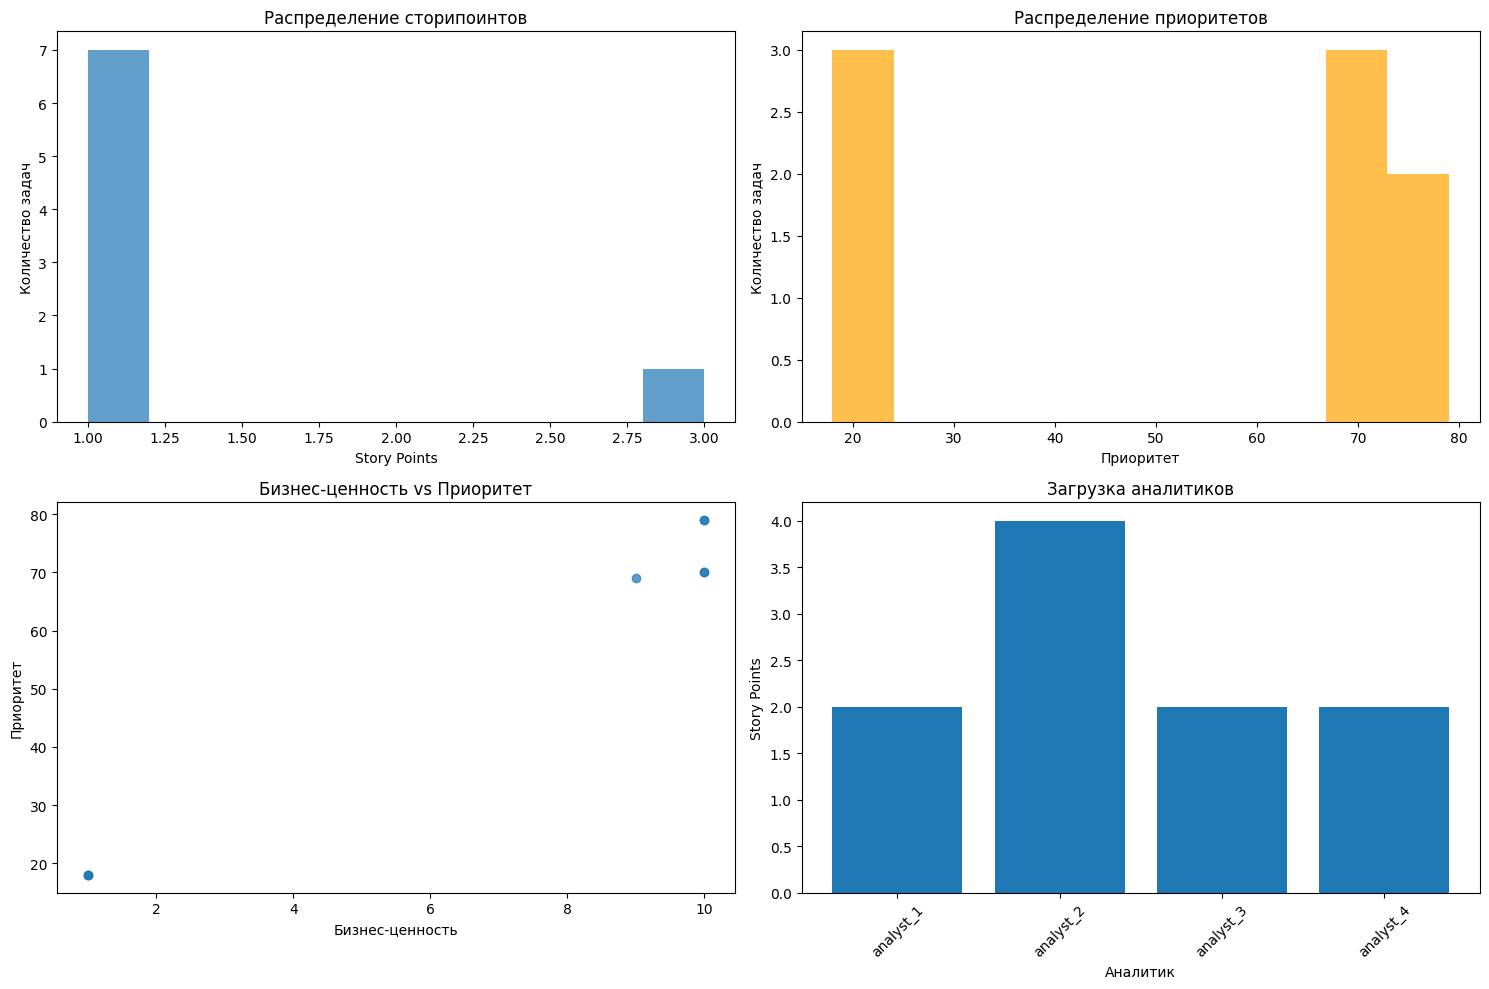


Результаты сохранены в sprint_plan_20260212_124944.csv


In [16]:
# Анализ результатов планирования
if 'sprint_plan' in locals():
    # Создание DataFrame для анализа
    analysis_data = []
    for task in sprint_plan.sprint_tasks:
        analysis_data.append({
            'issue_id': task.issue_id,
            'issue_summary': task.issue_summary,
            'story_points': task.estimated_story_points or 0,
            'priority': task.priority_score or 0,
            'business_value': task.business_value or 0,
            'urgency': task.urgency_score or 0,
            'assigned_analyst': task.assigned_analyst or 'Не назначен'
        })
    
    analysis_df = pd.DataFrame(analysis_data)
    
    print("Анализ спринта:")
    print(f"Средние значения:")
    print(f"  Сторипоинты: {analysis_df['story_points'].mean():.2f}")
    print(f"  Приоритет: {analysis_df['priority'].mean():.2f}")
    print(f"  Бизнес-ценность: {analysis_df['business_value'].mean():.2f}")
    
    print(f"\n📋 Топ-5 задач по приоритету:")
    top_priority = analysis_df.nlargest(5, 'priority')
    for _, row in top_priority.iterrows():
        print(f"  {row['issue_summary']} ({row['priority']:.1f}) - {row['assigned_analyst']}")
    
    # Визуализация (если нужно)
    try:
        import matplotlib.pyplot as plt
        import seaborn as sns
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Распределение сторипоинтов
        axes[0,0].hist(analysis_df['story_points'], bins=10, alpha=0.7)
        axes[0,0].set_title('Распределение сторипоинтов')
        axes[0,0].set_xlabel('Story Points')
        axes[0,0].set_ylabel('Количество задач')
        
        # Приоритеты
        axes[0,1].hist(analysis_df['priority'], bins=10, alpha=0.7, color='orange')
        axes[0,1].set_title('Распределение приоритетов')
        axes[0,1].set_xlabel('Приоритет')
        axes[0,1].set_ylabel('Количество задач')
        
        # Бизнес-ценность vs Приоритет
        axes[1,0].scatter(analysis_df['business_value'], analysis_df['priority'], alpha=0.7)
        axes[1,0].set_title('Бизнес-ценность vs Приоритет')
        axes[1,0].set_xlabel('Бизнес-ценность')
        axes[1,0].set_ylabel('Приоритет')
        
        # Загрузка аналитиков
        analyst_load = analysis_df.groupby('assigned_analyst')['story_points'].sum()
        axes[1,1].bar(analyst_load.index, analyst_load.values)
        axes[1,1].set_title('Загрузка аналитиков')
        axes[1,1].set_xlabel('Аналитик')
        axes[1,1].set_ylabel('Story Points')
        axes[1,1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()
        
    except ImportError:
        print("Визуализация недоступна (установите matplotlib и seaborn)")
    
    # Сохранение результатов
    output_file = f"sprint_plan_{datetime.now().strftime('%Y%m%d_%H%M%S')}.csv"
    analysis_df.to_csv(output_file, index=False, encoding='utf-8')
    print(f"\nРезультаты сохранены в {output_file}")